In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import pdist, squareform


# Preprocessing

In [4]:
df = pd.read_csv("Data/Wholesale customers data.csv")
print("Columns:", df.shape[1])
print("Rows:", df.shape[0])
df.info()
print(df.isnull().sum())
print(df.duplicated().sum())


Columns: 8
Rows: 440
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
0


In [5]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [6]:
# Select numerical columns
num_cols = df.columns.drop(['Channel', 'Region'])
df_processed = df.copy()
df_processed[num_cols] = np.log1p(df_processed[num_cols])   # Step 1: log
scaler = StandardScaler()
df_processed[num_cols] = scaler.fit_transform(df_processed[num_cols])  # Step 2: scale

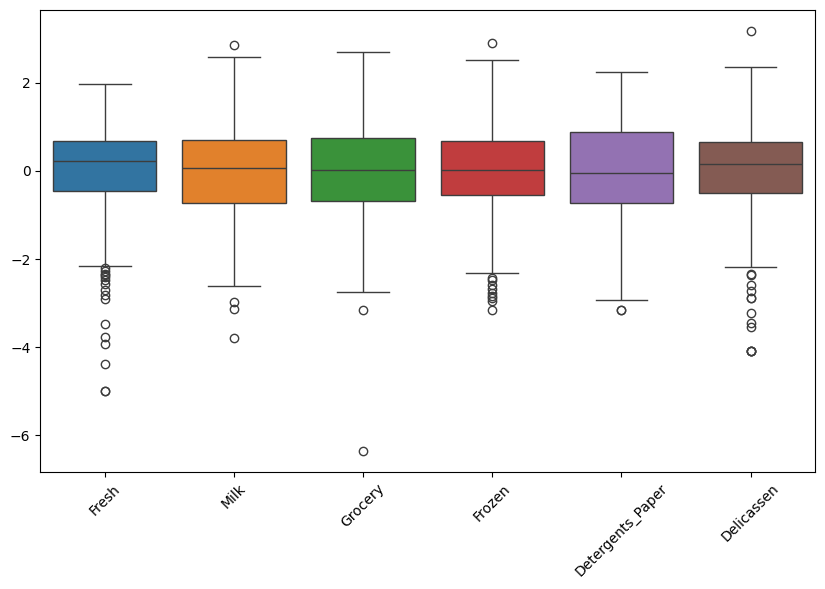

In [8]:
# Outlier detection
plt.figure(figsize=(10,6))
sns.boxplot(data=df_processed[num_cols])
plt.xticks(rotation=45)
plt.show()

The boxplots show outliers in several features after log transformation and scaling. These are data points that deviate significantly from the norm. For this analysis, we keep them as they may represent valid customer behaviors.

In [10]:
# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_processed[num_cols])

df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
print(pca.explained_variance_ratio_)
print("Total variance:", sum(pca.explained_variance_ratio_))

[0.44077752 0.27194917]
Total variance: 0.7127266893428759


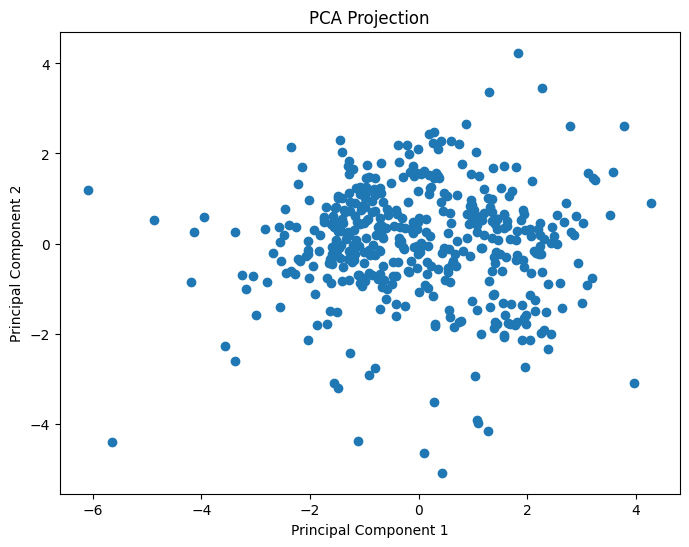

In [ ]:
# PCA Results Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca.assign(Channel=df['Channel']), x='PC1', y='PC2', hue='Channel')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection')
plt.show()

## PCA Explanation
- PCA was applied to reduce the dimensionality of the dataset.
- Since several numerical features are correlated, PCA transforms them into uncorrelated components while preserving most of the variance.
- The explained variance ratios show how much information each component captures. We use 2 components as they retain over 70% of the total variance, providing a good balance between simplicity and information preservation.
- The number of components was selected based on retaining the majority of the information.

# Visualization

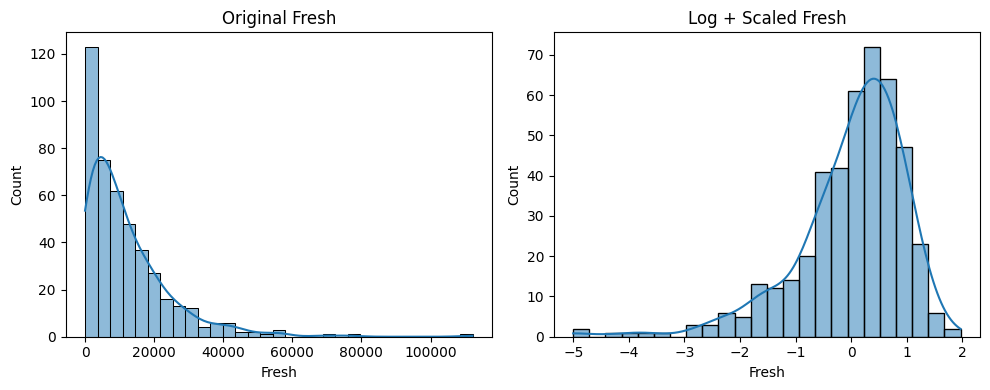

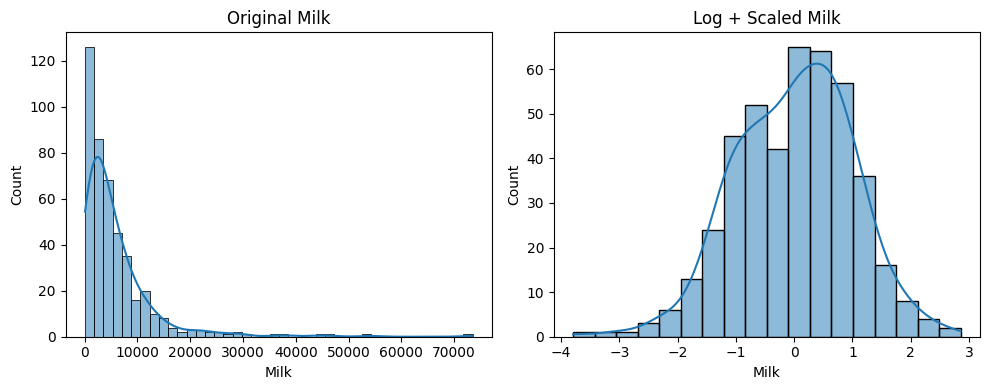

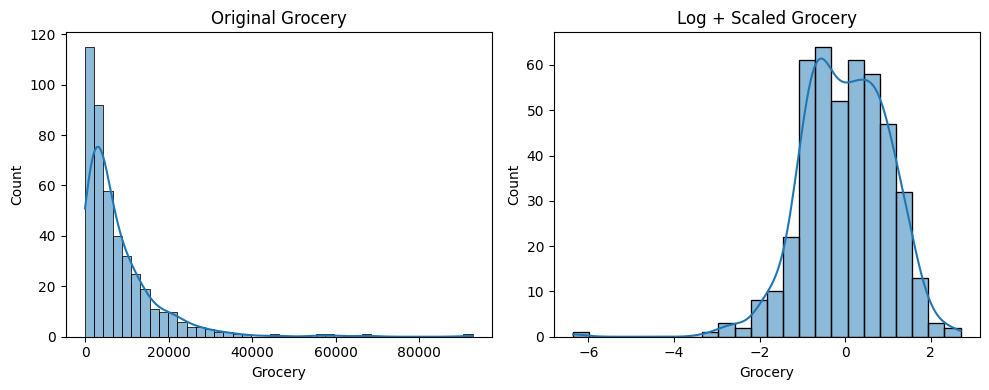

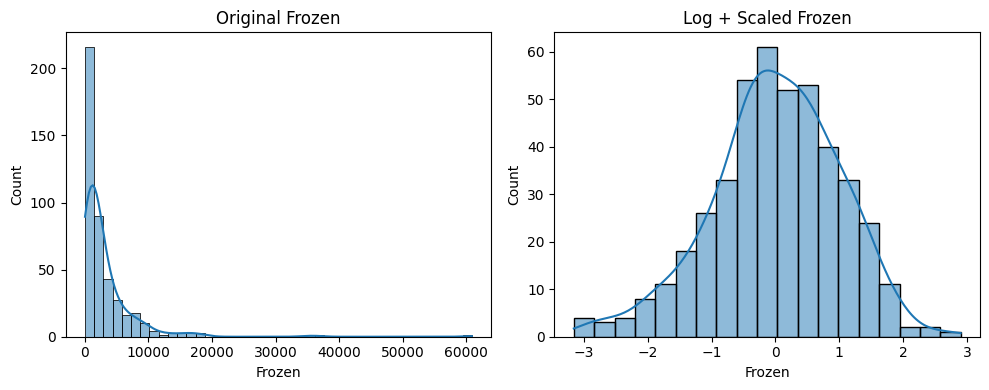

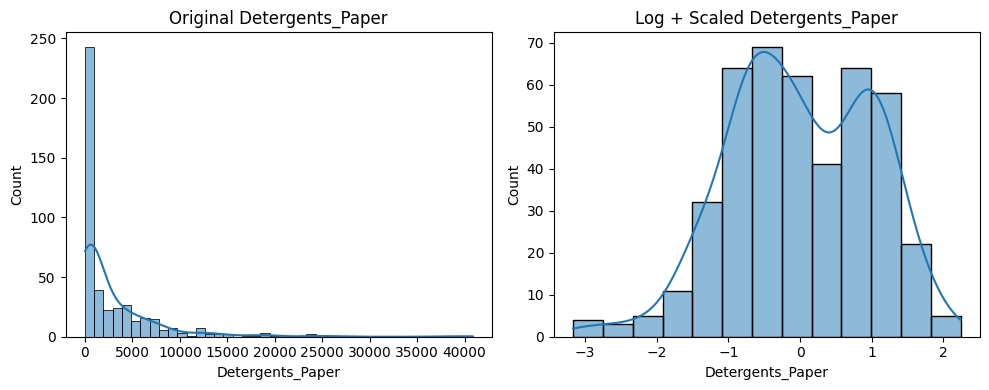

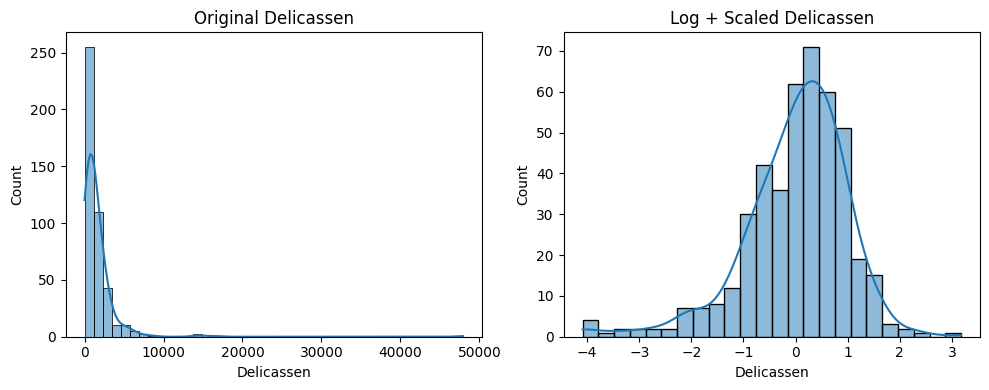

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Original {col}')

    plt.subplot(1,2,2)
    sns.histplot(df_processed[col], kde=True)
    plt.title(f'Log + Scaled {col}')

    plt.tight_layout()
    plt.show()

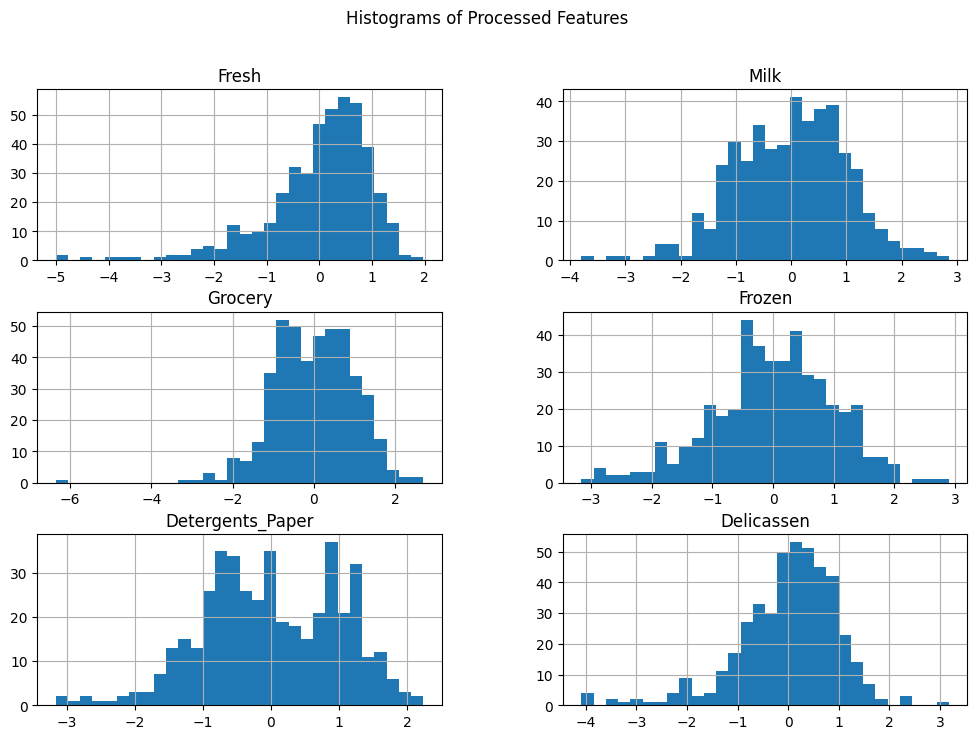

In [ ]:
df_processed[num_cols].hist(figsize=(12,8), bins=30)
plt.suptitle("Histograms of Processed Features")
plt.show()

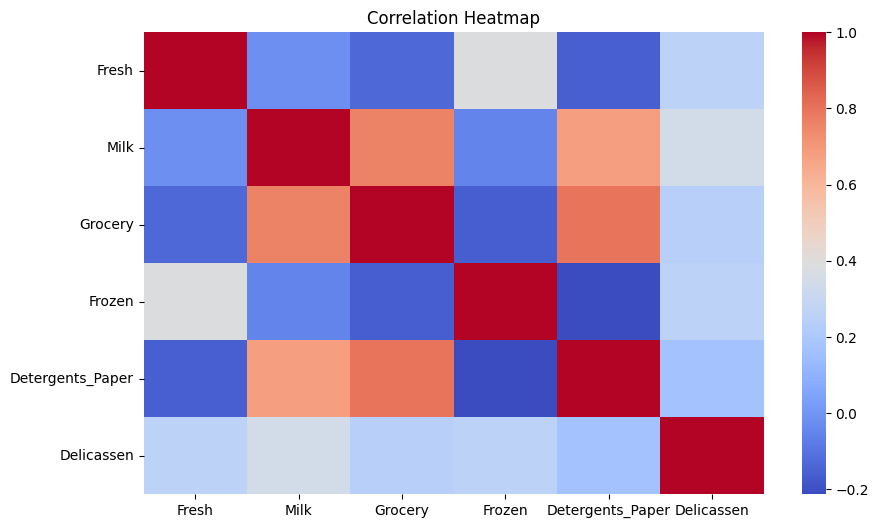

In [ ]:
plt.figure(figsize=(10,6))
corr_matridf_pca = df_processed[num_cols].corr()
sns.heatmap(corr_matridf_pca , cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

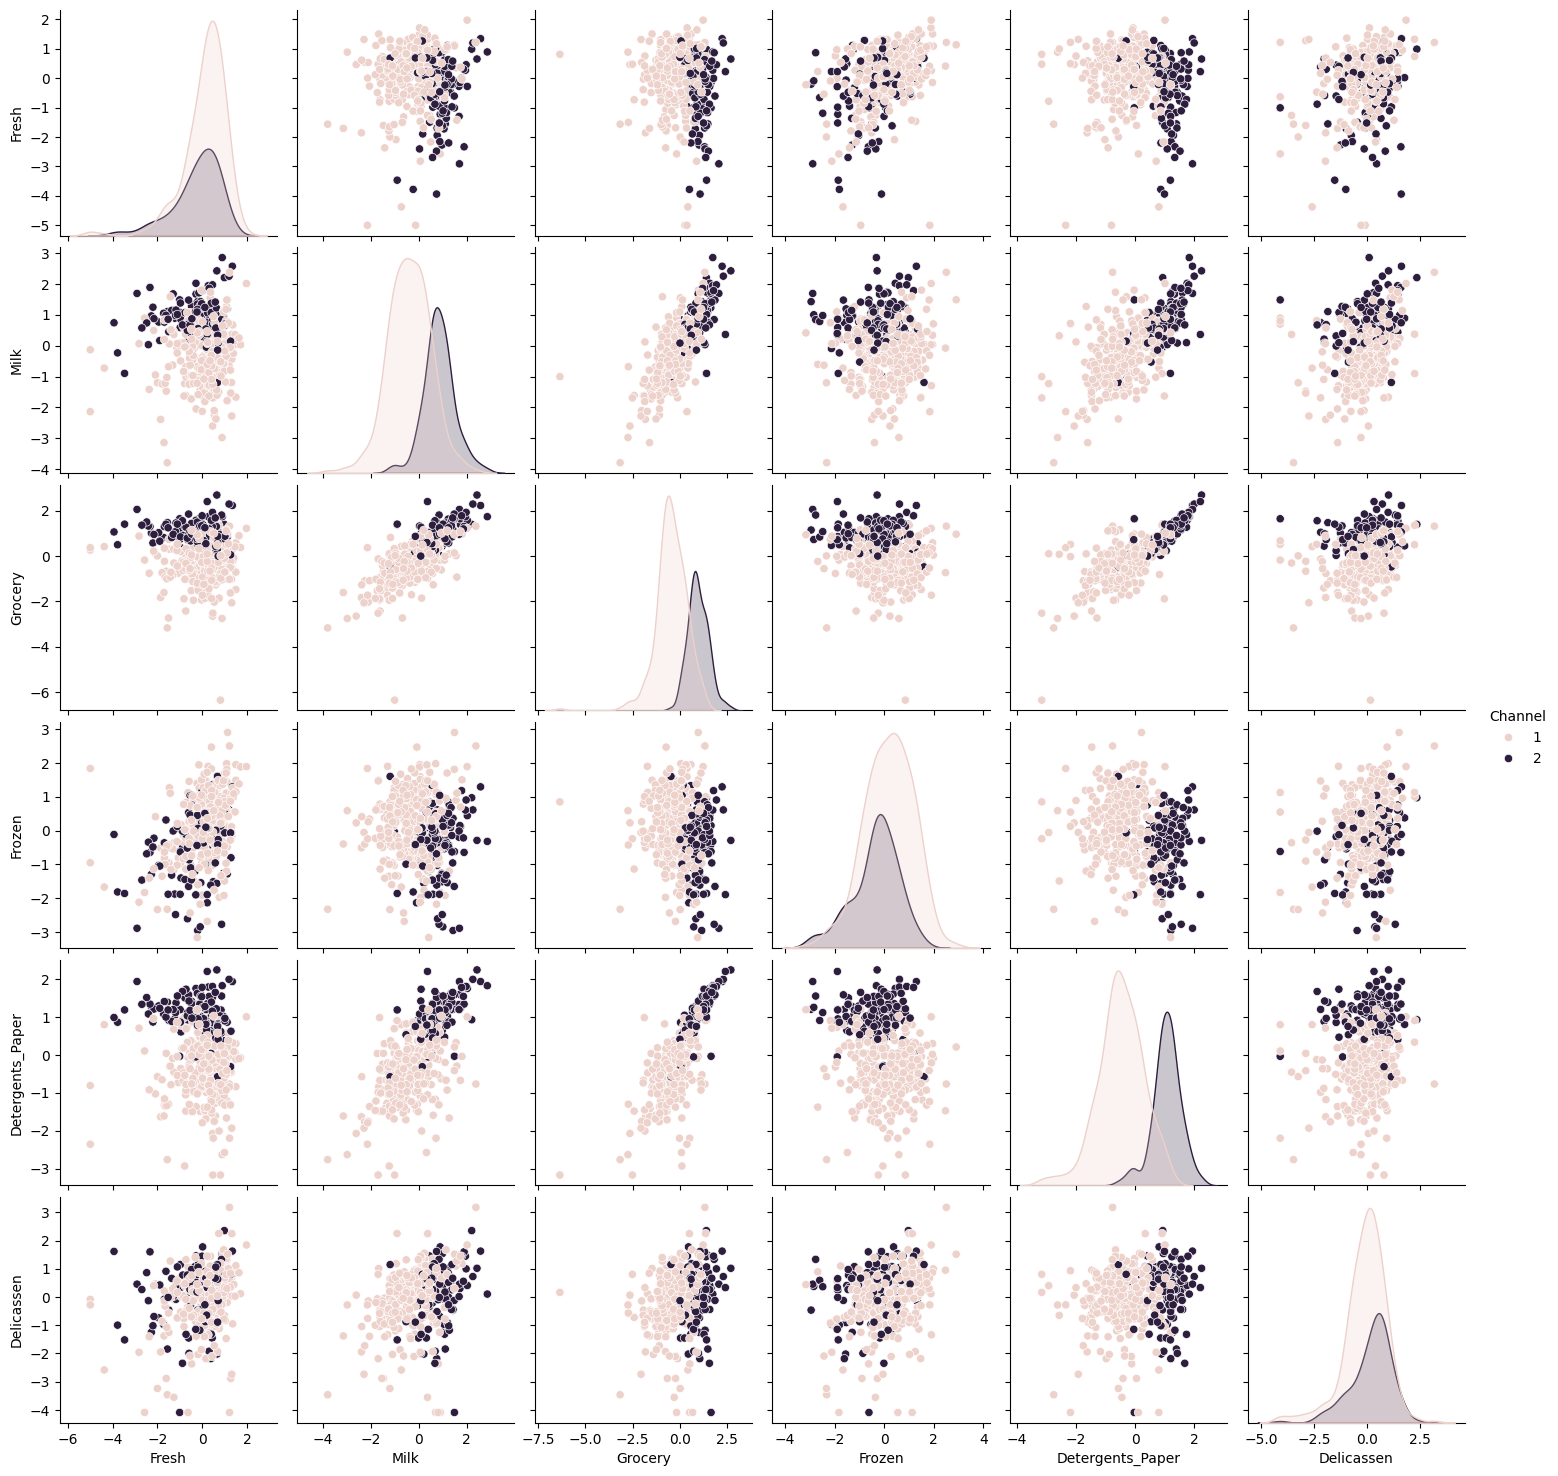

In [ ]:
selected_cols = num_cols[:4]  

sns.pairplot(df_processed[num_cols].join(df['Channel']), hue='Channel')
plt.show()

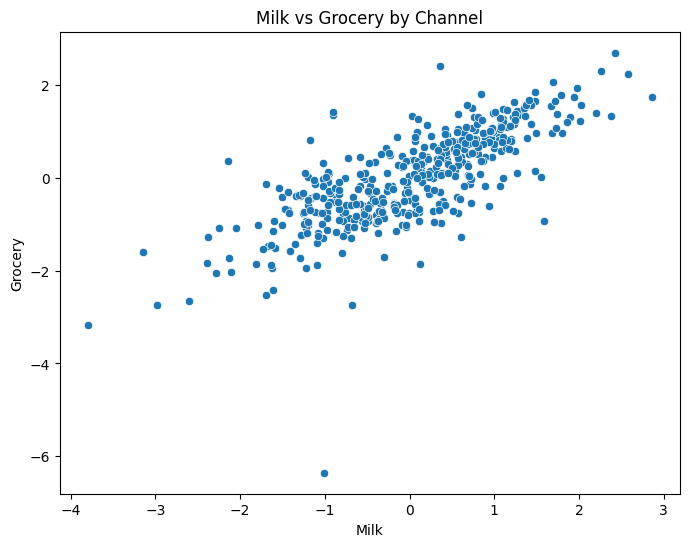

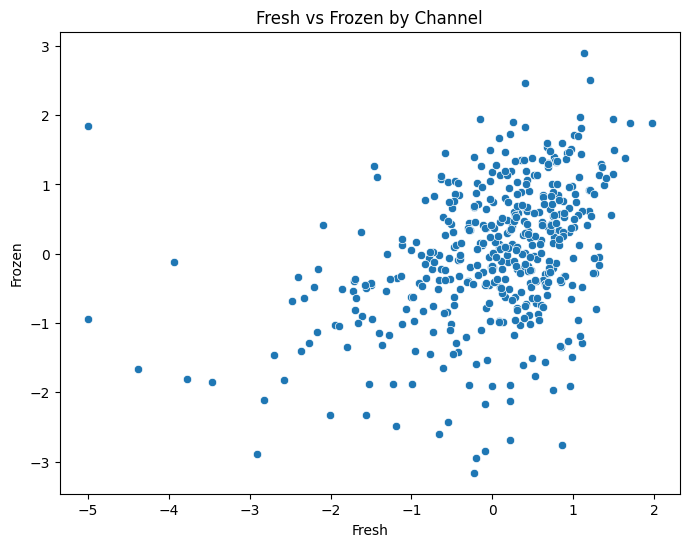

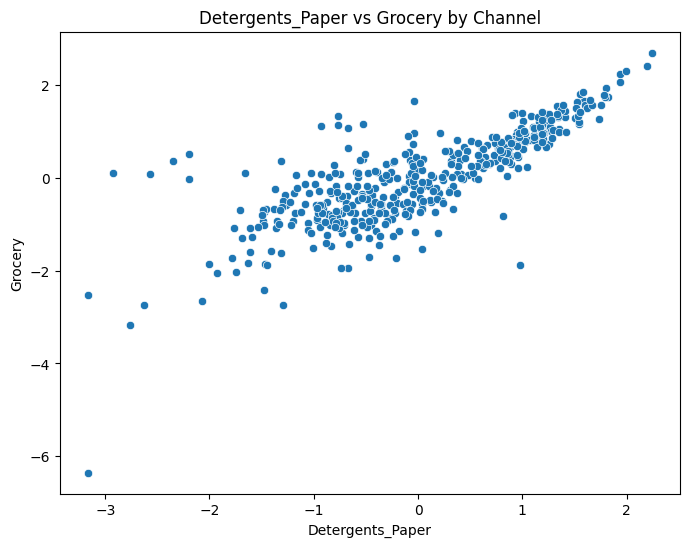

In [ ]:
pairs = [
    ('Milk', 'Grocery'),
    ('Fresh', 'Frozen'),
    ('Detergents_Paper', 'Grocery')
]

for x, y in pairs:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=df_processed[x], y=df_processed[y], hue=df['Channel'])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f'{x} vs {y} by Channel')
    plt.show()

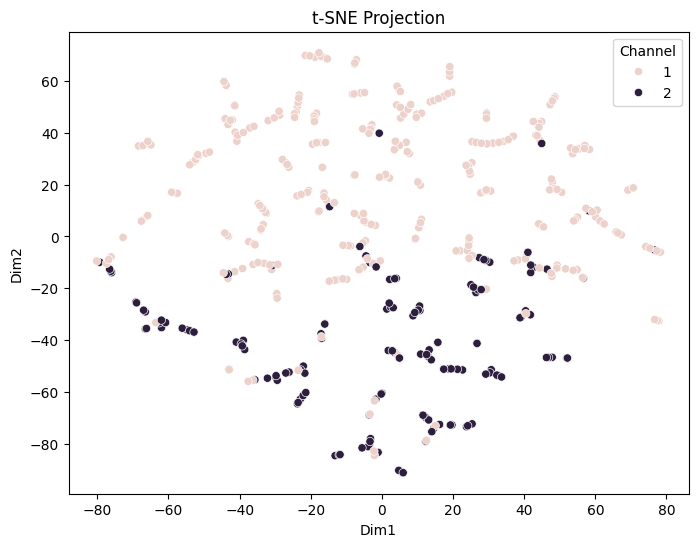

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(df_processed[num_cols])

df_tsne = pd.DataFrame(tsne_result, columns=['Dim1', 'Dim2'])
df_tsne['Channel'] = df['Channel']

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_tsne, x='Dim1', y='Dim2', hue='Channel')
plt.title('t-SNE Projection')
plt.show()

# Clustering


K-Means

In [ ]:
inertia = []
k_range = [2, 3, 4]
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

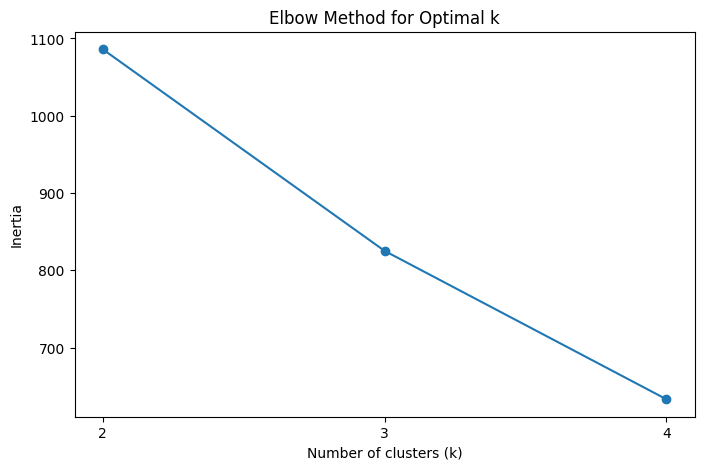

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, k_range):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_pca)
    
    sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=labels, palette='Set1', ax=ax)
    ax.set_title(f'K-Means Clustering (k={k})')

plt.tight_layout()
plt.show()

The Elbow Method suggests k=3 as the turning point where inertia decreases more slowly. However, evaluation metrics (Silhouette Score, etc.) show k=2 performs best overall. We prioritize metrics over the heuristic Elbow Method, as they provide quantitative measures of cluster quality.

Spectral Clustering

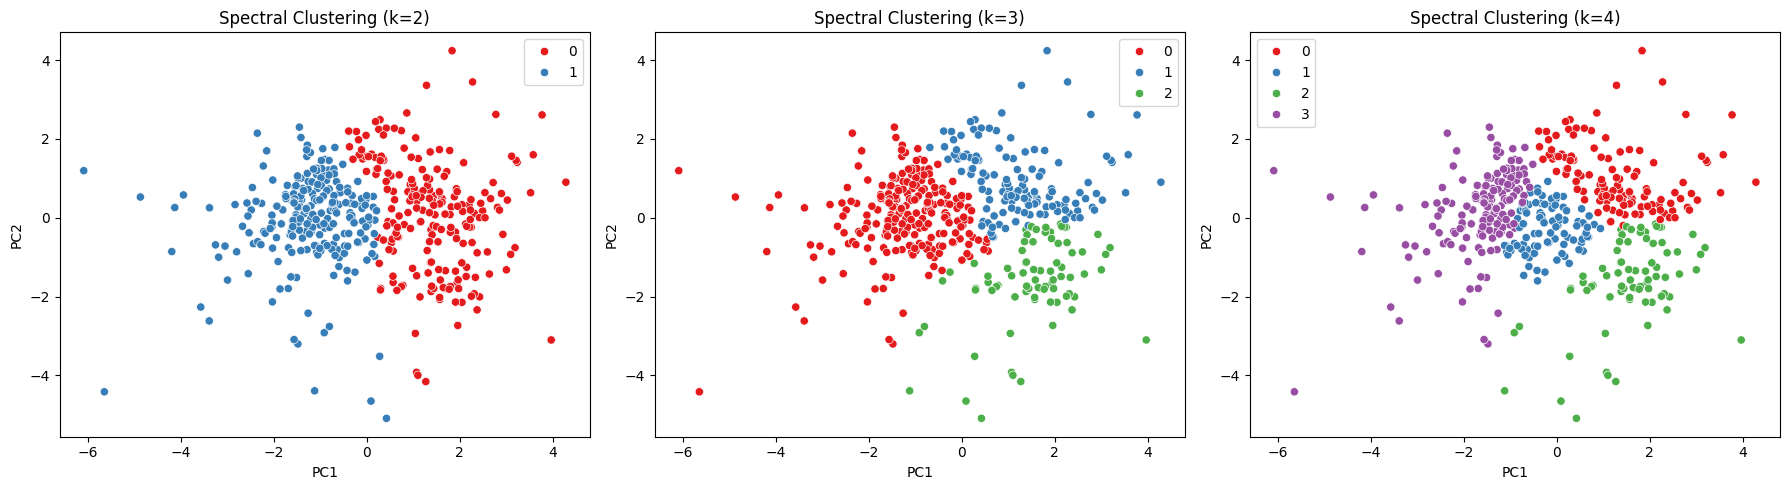

In [18]:
k_values = [2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, k in zip(axes, k_values):
    spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
    spectral_results = spectral.fit_predict(df_pca)

    sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=spectral_results, palette='Set1', ax=ax)

    ax.set_title(f'Spectral Clustering (k={k})')
plt.tight_layout()
plt.show()


# Gaussian Mixture Model (GMM)

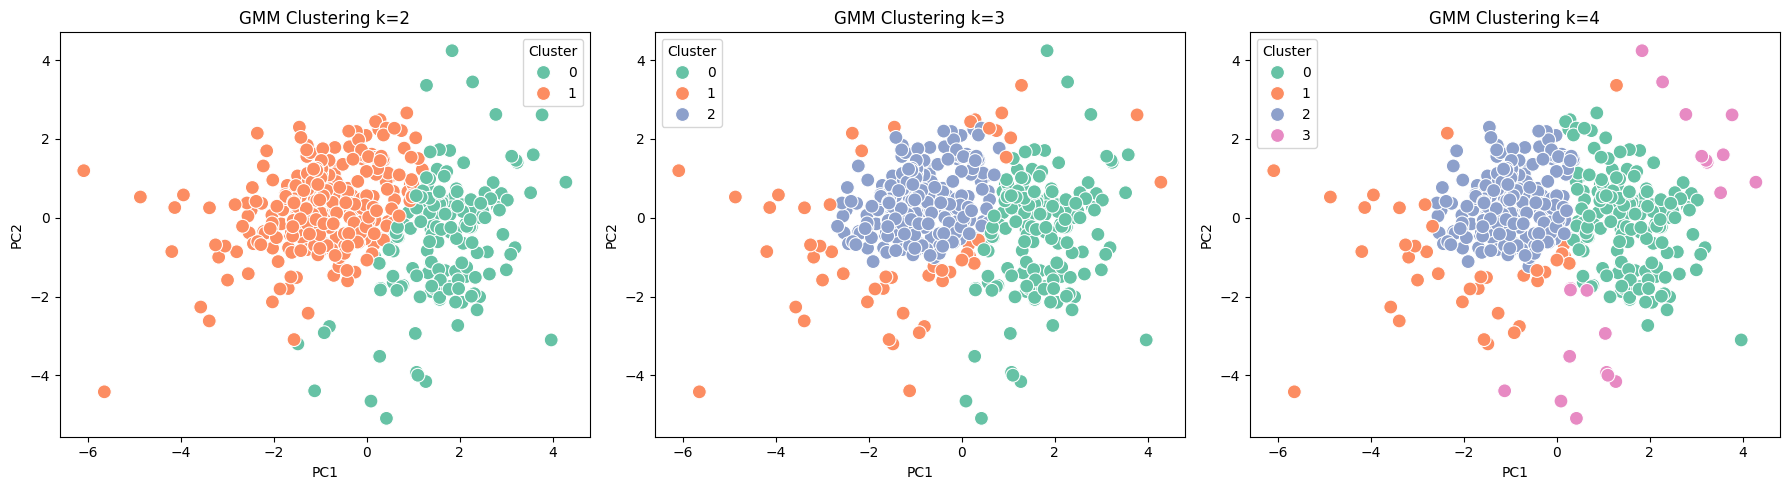

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
k_values = [2, 3, 4]
aic_values = []
bic_values = []

for ax, k in zip(axes, k_values):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm_predict = gmm.fit_predict(df_pca)
    aic_values.append(gmm.aic(df_pca))
    bic_values.append(gmm.bic(df_pca))

    df_plot = df_pca.copy()
    df_plot['cluster'] = gmm_predict

    sns.scatterplot(
        x='PC1', y='PC2',
        hue='cluster',
        palette='Set2',
        data=df_plot,
        ax=ax,
        s=100
    )
    ax.set_title(f'GMM Clustering k={k}')
    ax.legend(title='Cluster', loc='best')

plt.tight_layout()
plt.show()

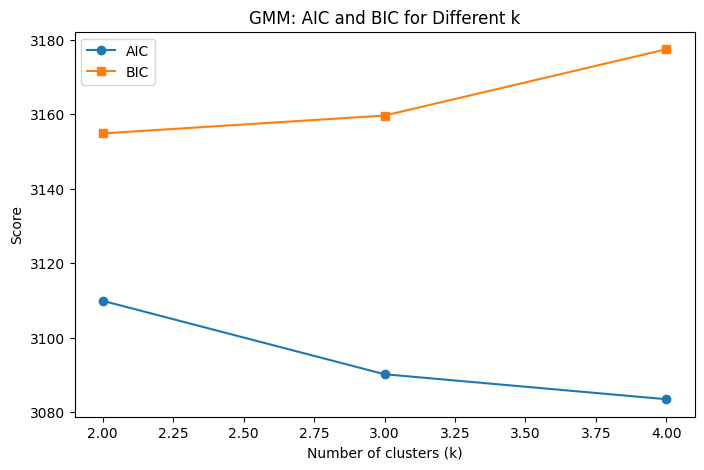

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_values, aic_values, marker='o', label='AIC')
plt.plot(k_values, bic_values, marker='s', label='BIC')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Score')
plt.title('GMM: AIC and BIC for Different k')
plt.legend()
plt.show()

AIC and BIC suggest k=3 as the turning point. However, evaluation metrics show k=2 performs better for GMM.

In [28]:
def dunn(X, labels):
    D = squareform(pdist(X))
    clusters = np.unique(labels)

    inter = np.min([D[np.ix_(labels==i, labels==j)].min()
                    for i in clusters for j in clusters if i < j])

    intra = np.max([D[np.ix_(labels==i, labels==i)].max()
                    for i in clusters])

    return inter / intra

In [29]:
def evaluate(X, labels):
    print("Silhouette:", silhouette_score(X, labels))
    print("DBI:", davies_bouldin_score(X, labels))
    print("CH:", calinski_harabasz_score(X, labels))
    print("Dunn:", dunn(X, labels))

In [30]:

for k in [2, 3, 4]:
    print(f"\nKMeans (k={k})")
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(df_pca)
    evaluate(df_pca.values, labels)


KMeans (k=2)
Silhouette: 0.40815681314927427
DBI: 0.9723549193833203
CH: 320.8883081854897
Dunn: 0.01843734065772936

KMeans (k=3)
Silhouette: 0.3277892117673151
DBI: 0.9821447936052522
CH: 279.75055031325724
Dunn: 0.00893594994456361

KMeans (k=4)
Silhouette: 0.331884176723404
DBI: 0.9679652761870295
CH: 286.54680718945525
Dunn: 0.01508936704177727


In [ ]:
for k in [2, 3, 4]:
    print(f"\nSpectral (k={k})")
    labels = SpectralClustering(n_clusters=k, random_state=42).fit_predict(df_pca.values)
    evaluate(df_pca.values, labels)


Spectral (k=2)
Silhouette: 0.40678767064052984
DBI: 0.9813571576367239
CH: 298.92409268249855
Dunn: 0.005525476772542414

Spectral (k=3)
Silhouette: 0.40125491122022533
DBI: 0.7789167313771973
CH: 202.25835744982686
Dunn: 0.011574504136538039

Spectral (k=4)
Silhouette: 0.3826313064356788
DBI: 0.7569958227202265
CH: 209.50419966418602
Dunn: 0.006811708354347905


In [32]:

for k in [2, 3, 4]:
    print(f"\nGMM (k={k})")
    labels = GaussianMixture(n_components=k, random_state=42).fit_predict(df_pca)
    evaluate(df_pca.values, labels)


GMM (k=2)
Silhouette: 0.39969035178685264
DBI: 1.012702561482768
CH: 286.2252224981375
Dunn: 0.008623897287010913

GMM (k=3)
Silhouette: 0.35596702811115866
DBI: 2.815077477197383
CH: 156.08482329477786
Dunn: 0.012288214421174629

GMM (k=4)
Silhouette: 0.34531270965809446
DBI: 3.619121674944803
CH: 133.50375111878552
Dunn: 0.01098970181327304


### Clustering Evaluation

Clustering performance was evaluated using Silhouette Score, Davies–Bouldin Index (DBI), Calinski–Harabasz Index (CH), and Dunn Index.

For K-Means, k=2 achieved the best performance with the highest Silhouette Score (0.408), highest Calinski–Harabasz Index (320.88), and highest Dunn Index (0.0184), indicating well-separated and compact clusters.

Spectral Clustering also performed reasonably well for k=2, but showed less consistency across all evaluation metrics.

Gaussian Mixture Models (GMM) produced weaker results, with lower Silhouette scores and significantly higher DBI values, indicating poorer cluster separation.

Overall, K-Means with k=2 outperformed all other models and configurations, providing the best balance between cluster compactness and separation.

Therefore, the optimal clustering model for this dataset is K-Means with k=2.

### Results Analysis

#### Comparison between Clustering Algorithms
K-Means outperformed Spectral Clustering and Gaussian Mixture Models across most evaluation metrics. It achieved the highest Silhouette Score, Calinski–Harabasz Index, and Dunn Index, indicating better cluster separation and compactness. Spectral Clustering showed moderate performance, while GMM had weaker results with higher Davies–Bouldin Index values.

#### Impact of Number of Clusters (K)
The number of clusters significantly affected performance. K=2 consistently produced the best results across all algorithms. Increasing K to 3 or 4 reduced clustering quality, as shown by lower Silhouette scores and higher DBI values. The Elbow Method suggested k=3, but metrics prioritize k=2.

#### Visualization of Clustering Results
The PCA plots show that the data forms two main groups with some overlap. K-Means with k=2 provides the clearest separation between clusters, while Spectral and GMM show more overlap and less defined boundaries.

#### Interpretation of Evaluation Metrics
- Silhouette Score: Higher values indicate better separation → best for K-Means (k=2)
- Davies–Bouldin Index: Lower values indicate better clustering → K-Means performed well
- Calinski–Harabasz Index: Higher values indicate dense clusters → K-Means achieved highest score
- Dunn Index: Higher values indicate compact clusters → best in K-Means

Overall, K-Means with k=2 achieved the best balance between cluster separation and compactness.

#### Cluster Profiling
Cluster analysis shows that one group of customers has higher spending across most product categories, while the other group represents lower or moderate spending. This indicates a natural segmentation between high-value and low-value customers.

In [ ]:

# Apply best model
kmeans = KMeans(n_clusters=2, random_state=42)
df_processed['Cluster'] = kmeans.fit_predict(df_pca)

# Compute mean values per cluster
cluster_profile = df[num_cols].groupby(df_processed['Cluster']).mean()

print(cluster_profile)

Cluster 0 represents high-spending customers with higher averages across most categories, while Cluster 1 represents low-spending customers. This segmentation helps identify different customer groups for targeted marketing.

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca.assign(Cluster=df_processed['Cluster']), x='PC1', y='PC2', hue='Cluster')
plt.title("Final Clustering (K-Means, k=2)")
plt.show()

The final clustering visualization shows two main groups of customers with clear separation. K-Means with k=2 is the optimal choice, supported by strong evaluation metrics and practical interpretability for customer segmentation.